<a href="https://colab.research.google.com/github/chadiboudaher/classification-make-moons-dataset-pytorch/blob/main/make_moons_classification_using_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/chadiboudaher/classification-make-moons-dataset-pytorch.git

Cloning into 'classification-make-moons-dataset-pytorch'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [11]:
import torch
from torch import nn
# Setup agnostic device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"The device used is: {device}")

The device used is: cuda


## 1. Make a binary classification dataset with scikit-learn's make_moons() function

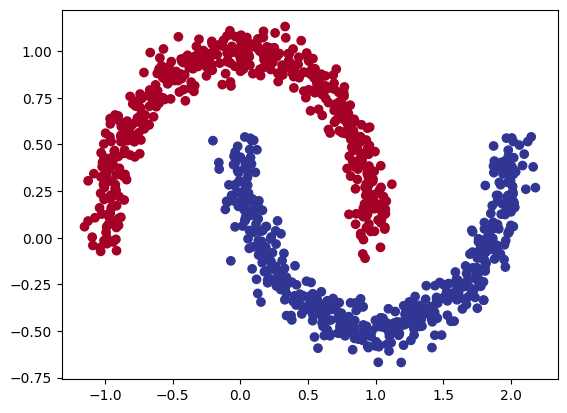

In [38]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

RANDOM_SEED = 42
NUM_SAMPLES = 1000

# Create a dataset
X, y = make_moons(n_samples=NUM_SAMPLES,
                  noise=0.07,
                  random_state=RANDOM_SEED)

# print(f"Snipped of the data: {X[:5]}")
# print(f"Snipped of the labels: {y[:5]}")
# print(f"Data shape: {X.shape}")
# print(f"Labels shape: {y.shape}")

df = pd.DataFrame({
    "X1": X[:, 0],
    "X2": X[:, 1],
    "y": y
})

# df.head()

# Turn the Data into tensors of dtype float for X and long for y (req for classifcation)
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split the dataset into training and test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=RANDOM_SEED)

# print(f"Snipped of training data: {X_train[:5]}")
# print(f"Snipped of training labels: {y_train[:5]}")
# print(f"Training data shape: {X_train.shape}")
# print(f"Training labels shape: {y_train.shape}")

# Plot the data
plt.scatter(X[:, 0],
            X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

## 2. Build a model that incorporate non-linear activation functions and is capable of fitting the data.


In [39]:
class MoonModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=4):
    super().__init__()

    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer_stack(x)

model = MoonModel(input_features=2,
                  output_features=1,
                  hidden_units=10).to(device)

model

MoonModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

## 3. Setup binary classification loss function and optimizer to use when training the model built

In [40]:
# Setup loss function
loss_fn = nn.BCEWithLogitsLoss()

# Setup optimizer to optimize model parameters ( SGD or Adam )
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.1)

In [41]:
# Calculate Accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [29]:
!pip -q install torchmetrics

In [42]:
from torchmetrics import Accuracy

acc_fn = Accuracy(task="multiclass", num_classes=2).to(device)

In [43]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 500

for epoch in range(epochs):
  model.train()

  y_logits = model(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  accuracy = acc_fn(y_pred, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_accuracy = acc_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.5f} | Accuracy: {accuracy:.2f} | Test Loss: {test_loss:.5f} | Test Accuracy: {test_accuracy:.2f}")

Epoch: 0 | loss: 0.69532 | Accuracy: 0.37 | Test Loss: 0.64290 | Test Accuracy: 0.64
Epoch: 100 | loss: 0.00015 | Accuracy: 1.00 | Test Loss: 0.00009 | Test Accuracy: 1.00
Epoch: 200 | loss: 0.00006 | Accuracy: 1.00 | Test Loss: 0.00004 | Test Accuracy: 1.00
Epoch: 300 | loss: 0.00004 | Accuracy: 1.00 | Test Loss: 0.00003 | Test Accuracy: 1.00
Epoch: 400 | loss: 0.00003 | Accuracy: 1.00 | Test Loss: 0.00002 | Test Accuracy: 1.00


In [44]:

# Plot the model predictions

import numpy as np

# TK - this could go in the helper_functions.py and be explained there
def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


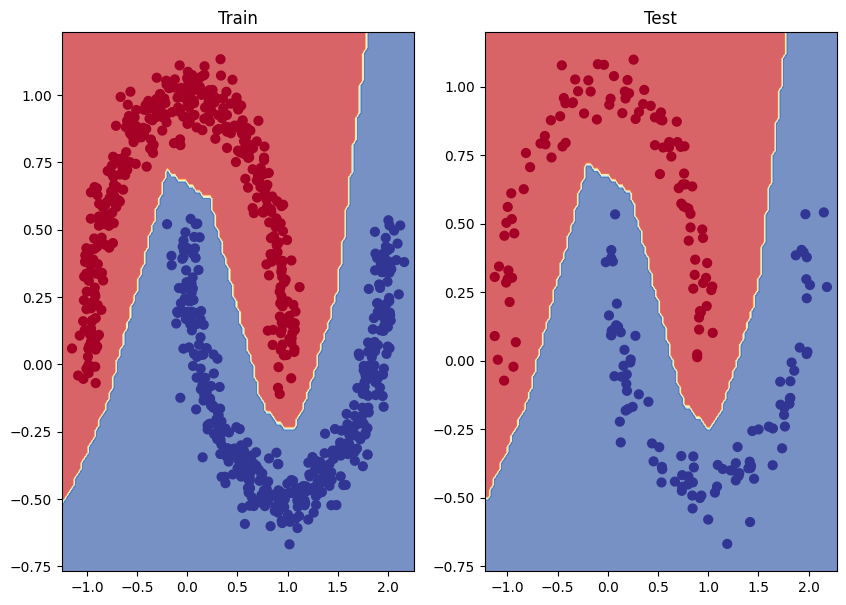

In [46]:
plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
plt.show()